In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

import scipy.stats as stats

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [8]:
df = pd.read_csv('concrete_data.csv')

In [9]:
df.shape

(1030, 9)

In [10]:
# predecting strength
# applying BoxCox transformer : which required non zeros and positive values only

df.describe()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [11]:
X = df.drop(columns=["Strength"])
Y = df.iloc[:,-1]

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [13]:
#  Applying regression without any transformation
lr = LinearRegression()
lr.fit(X_train,Y_train)
Y_pred = lr.predict(X_test)
r2_score(Y_test,Y_pred)

0.6275531792314848

In [15]:
# Cross validation with cross val score
lr = LinearRegression()
print(np.mean(cross_val_score(lr,X,Y,scoring='r2')))

0.4609940491662864


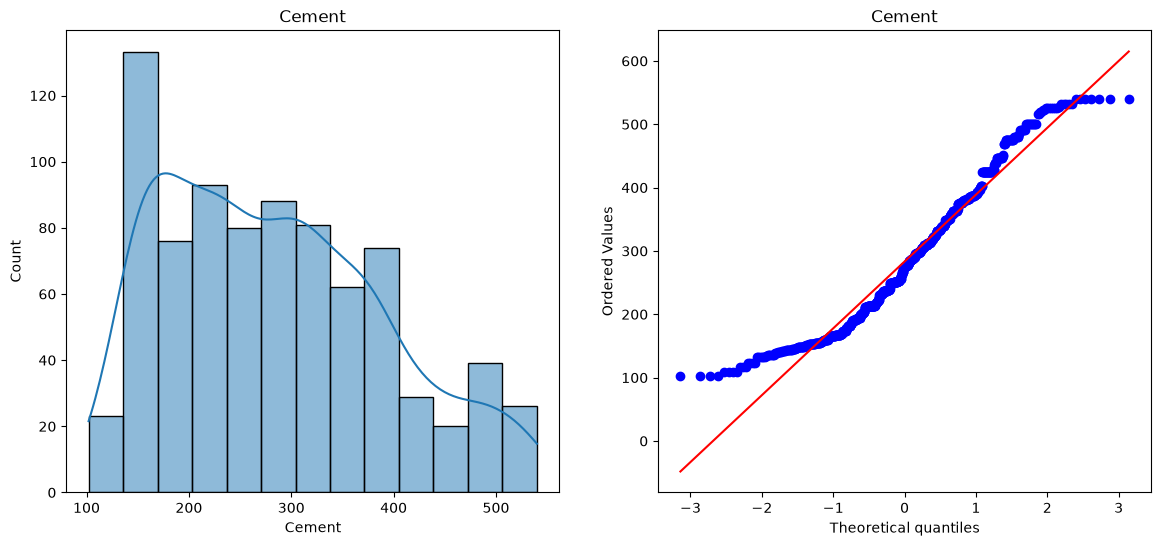

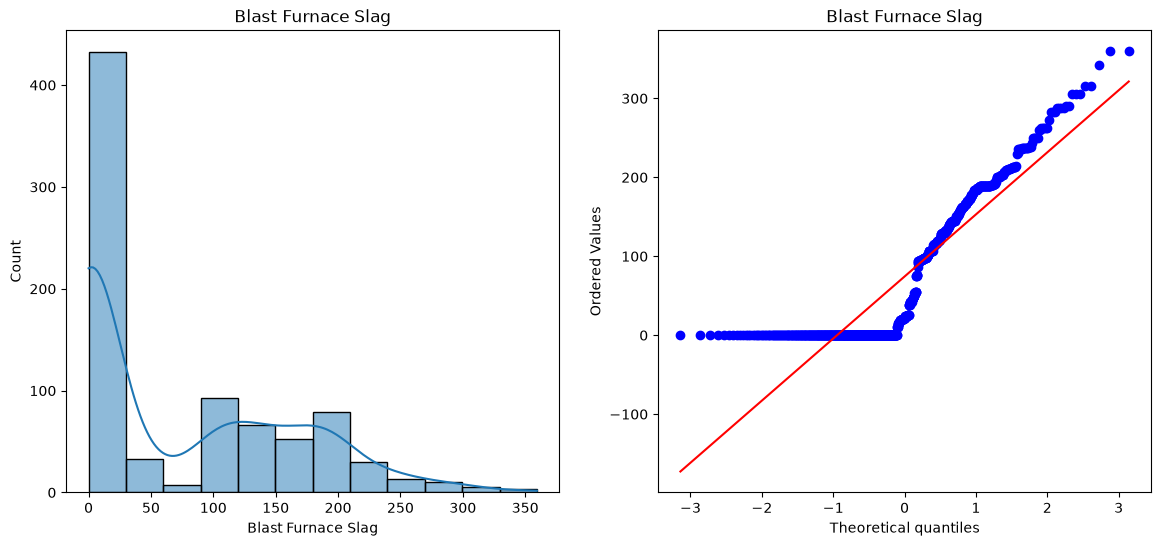

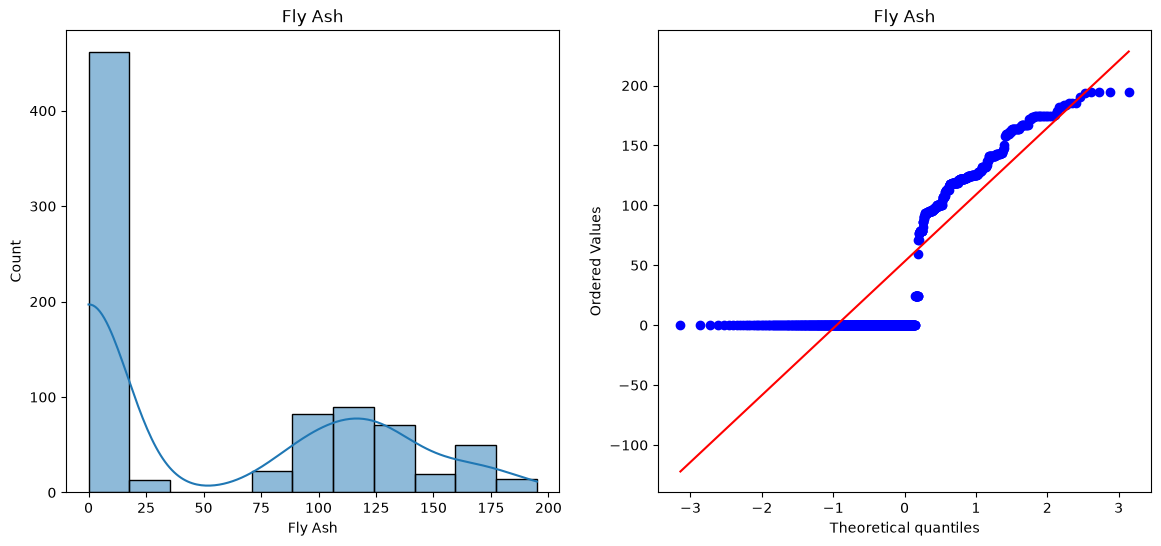

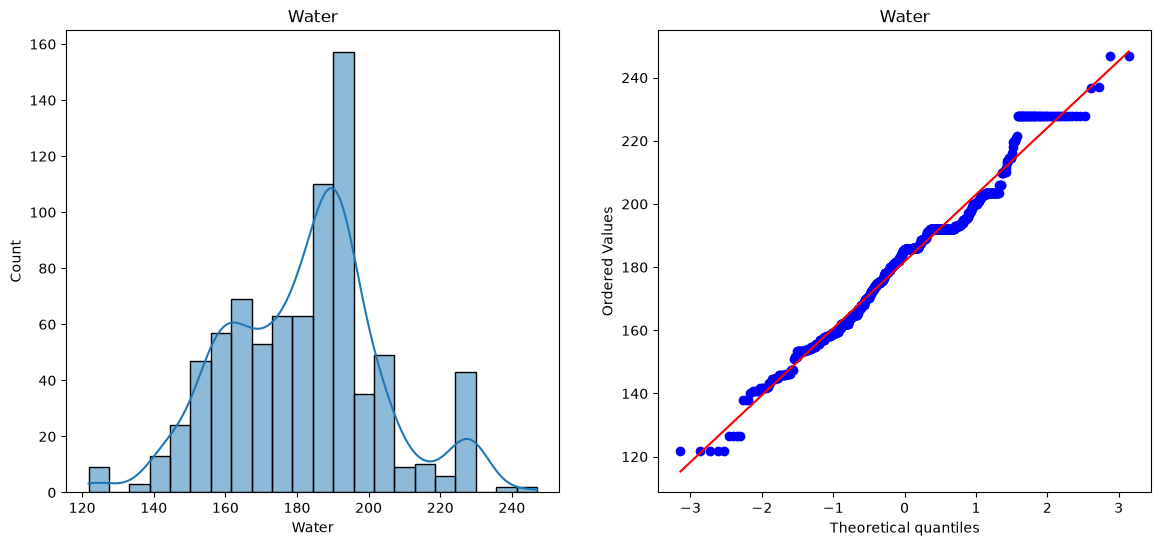

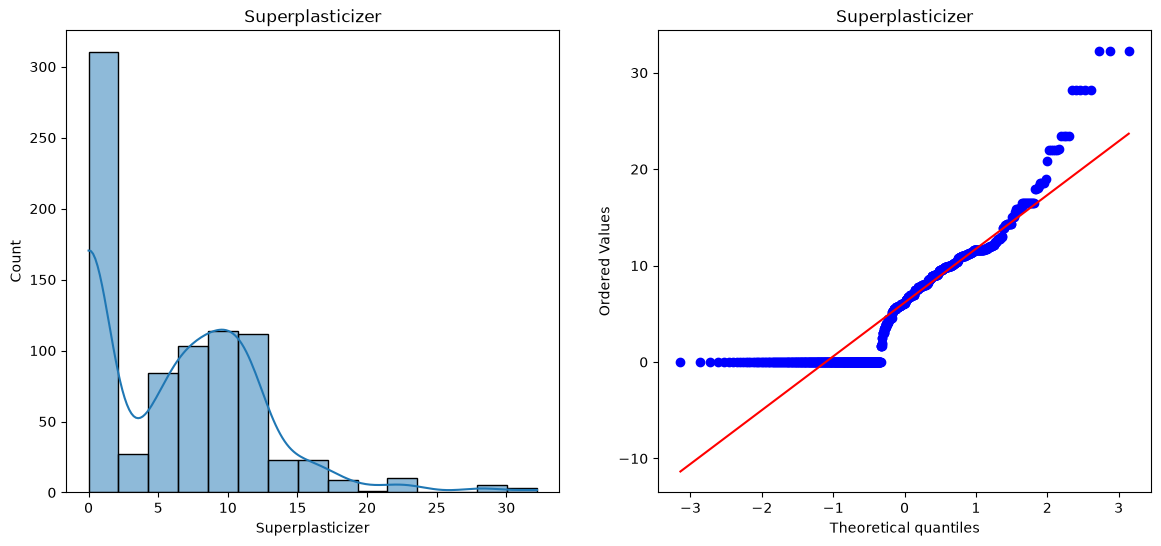

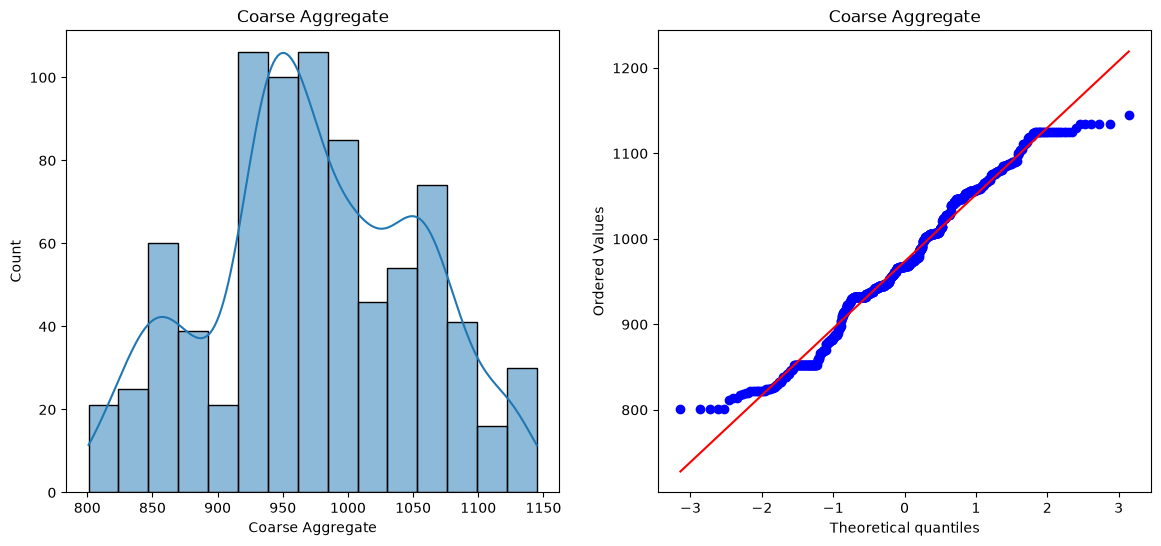

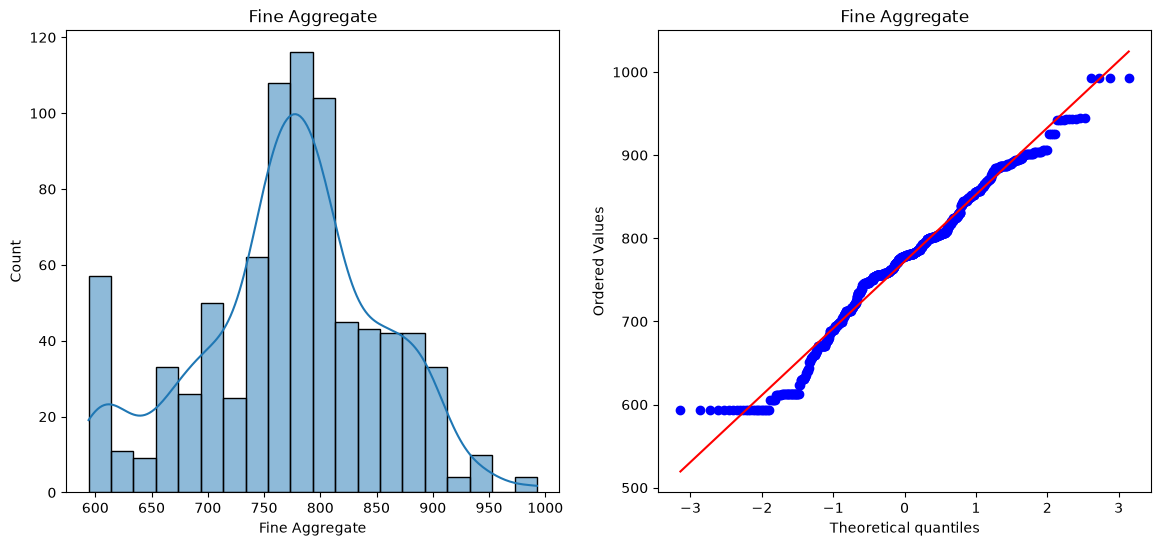

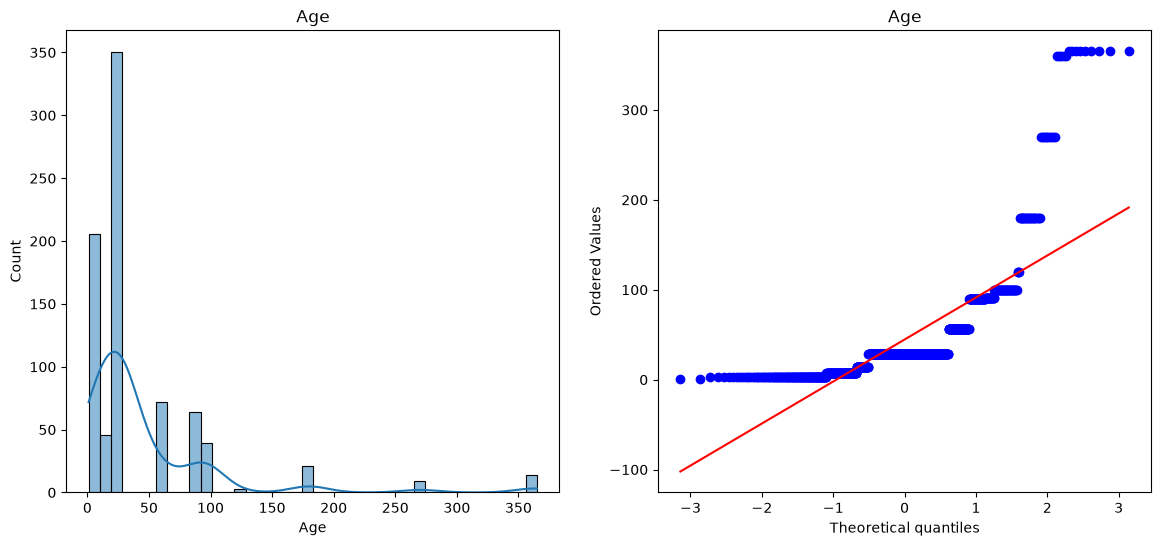

In [ ]:
for col in X_train.columns:
    plt.figure(figsize=(14, 6)) 

    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)   # axes-level, respects subplot
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [22]:
#  Applyiing Box Cox transformer
pt = PowerTransformer(method='box-cox')
X_train_transformed = pt.fit_transform(X_train+0.00001)
X_test_transformed = pt.fit_transform(X_test+0.00001)

pd.DataFrame({'cols ':X_train.columns,'box_cox_lamdas':pt.lambdas_})

,cols,box_cox_lamdas
0,Cement,0.215602
1,Blast Furnace Slag,0.028899
2,Fly Ash,-0.007561
3,Water,0.959062
4,Superplasticizer,0.119398
5,Coarse Aggregate,1.192491
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [23]:
#  Applying Linear Regression on transformed data
lr = LinearRegression()
lr.fit(X_train_transformed,Y_train)
y_pred2 = lr.predict(X_test_transformed)
r2_score(Y_test,y_pred2)

0.8061415974444238

In [26]:
# Using cross validation
pt = PowerTransformer(method="box-cox")
X_Transformed = pt.fit_transform(X+0.000001)
lr = LinearRegression()
np.mean(cross_val_score(lr,X_Transformed,Y,scoring='r2'))


np.float64(0.6662950326831086)

In [33]:
for col in X_train_transformed.columns:
    plt.figure(figsize=(14, 6)) 

    plt.subplot(121)
    sns.histplot(X_train_transformed[col], kde=True)   # axes-level, respects subplot
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'